# Datalab 2 - Sprint 2
## groep 6 : 
- Ardjun Debi - Tewarie (25032895)
- Azfar Mohab Ali (25026356)
- Tesja Kartomo (25035193)
- Shelby Gibbs (18005055)

## Import en connectie met de database

Hier maken we gebruik van een `DatabaseViewer` class die de verbinding met de database (`./assets/database.sqlite`) opzet en functies bevat om SQL queries uit te voeren en zowel volledige resultaten als een preview (eerste rij) weer te geven.

In [48]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


class DatabaseViewer:
    """
    Klasse voor het verbinden met en bekijken van data uit een SQLite database.

    Attributes
    ----------
    db_path : str
        Pad naar de database.
    conn : sqlite3.Connection
        Actieve databaseverbinding.
    """

    def __init__(self, db_path="./assets/database.sqlite"):
        """
        Initialiseert de databaseverbinding.

        Parameters
        ----------
        db_path : str, optional
            Pad naar de SQLite database (standaard './assets/database.sqlite').
        """
        self.db_path = db_path
        self.conn = sqlite3.connect(db_path)
        print(f"Database connectie is gemaakt met: {db_path}")

    def show_query(self, query):
        """
        Voert een SQL-query uit.

        Parameters
        ----------
        query : str
            De SQL-query die uitgevoerd moet worden.

        Returns
        -------
        DataFrame
            Toont het resultaat als pandas DataFrame.
        """
        df = pd.read_sql_query(query, self.conn)
        display(df)
        return df

    def show_head_query(self, query):
        """
        Voert een SQL-query uit en toont de eerste rij.

        Parameters
        ----------
        query : str
            De SQL-query die uitgevoerd moet worden.

        Returns
        -------
        Eerste rij dataframe
            Toont alleen de eerste rij van het resultaat.
        """
        df = pd.read_sql_query(query, self.conn)
        display(df.head(1))


bar = DatabaseViewer()


Database connectie is gemaakt met: ./assets/database.sqlite


## Stap 1: team_api_id van Barcelona vinden

- **Stap 1:** Zoek in de tabel **Team** naar de `team_api_id` van **FC Barcelona**. Deze identifier gebruiken we later om wedstrijden van dit team te vinden.

In [49]:
# stap 1: vind de team_api_id van FC Barcelona
bar.show_query("""
SELECT team_long_name, team_api_id
FROM Team
WHERE team_long_name = 'FC Barcelona';
""")


,team_long_name,team_api_id
0,FC Barcelona,8634


,team_long_name,team_api_id
0,FC Barcelona,8634


## Stap 2: Matches van Barcelona vinden

- **Stap 2:** Zoekt naar wedstrijden waarin Barcelona speelt door `team_api_id` (8634) in de tabel **Match** te filteren. Hierbij kijken we zowel naar `home_team_api_id` als `away_team_api_id`.

In [50]:
# stap 2: vind de matches door middel van team_api_id van barcelona
bar.show_query("""
SELECT
  Match.id,
  Match.season,
  Match.country_id,
  Match.league_id,
  Match.home_team_api_id,
  Match.away_team_api_id
FROM Match
WHERE Match.home_team_api_id = 8634
   OR Match.away_team_api_id = 8634
LIMIT 5;
          
""")

,id,season,country_id,league_id,home_team_api_id,away_team_api_id
0,21521,2008/2009,21518,21518,8388,8634
1,21535,2008/2009,21518,21518,8634,10281
2,21547,2008/2009,21518,21518,8479,8634
3,21550,2008/2009,21518,21518,8634,8305
4,21564,2008/2009,21518,21518,8302,8634


,id,season,country_id,league_id,home_team_api_id,away_team_api_id
0,21521,2008/2009,21518,21518,8388,8634
1,21535,2008/2009,21518,21518,8634,10281
2,21547,2008/2009,21518,21518,8479,8634
3,21550,2008/2009,21518,21518,8634,8305
4,21564,2008/2009,21518,21518,8302,8634


## Stap 3: League van Barcelona bepalen

- **Stap 3.1:** Zoek de `league_id` van een wedstrijd waarin Barcelona speelt.  
- **Stap 3.2:** Zoek de `country_id` van deze wedstrijd.  
- **Stap 3.3:** Gebruik de `country_id` om de naam van de **League** te vinden.

In [51]:
# stap 3: vind de league_id's en de naam van de league van de matches van barcelona
# stap 3.1: vind de league id
bar.show_query(
"""
SELECT Match.league_id
FROM Match
WHERE Match.home_team_api_id = 8634 OR Match.away_team_api_id = 8634
LIMIT 1;
""")

# stap 3.2: vind eerste de country id om makkelijjker te zoeken naar de name van de League
bar.show_query(
"""
SELECT Match.country_id
FROM Match
WHERE home_team_api_id = 8634
LIMIT 1
"""
)
# stap 3.3 vind nu de naam van de league:
bar.show_query(
"""
SELECT League.Name
FROM League
WHERE country_id = 21518
LIMIT 1
"""
)



,league_id
0,21518


,country_id
0,21518


,name
0,Spain LIGA BBVA


,name
0,Spain LIGA BBVA


## Belangrijke variablen
- Team : **Barcelona**
- `Team_api_id`, `home_team_api_id`, `away_team_api_id` : 8634
- `Country_id`, `League_id` : 21518
- `League.Name` : Spain LIGA BBVA

## Relaties:
### Tabel met relaties:
| Kolom| Van tabel | Naar tabel | Naar kolom | Beschrijving|
| ------------------ | ----------------- | ---------- | ------------------ | ----------------------------------------------------------------------- |
| country_id | League| Country| id | Geeft aan in welk land de **competitie plaatsvindt**. |
| country_id | Match | Country| id | Geeft aan in welk land de **wedstrijd gespeeld** wordt. |
| league_id| Match | League | id | **Verbindt** een wedstrijd aan de competitie waarin deze gespeeld wordt.|
| home_team_api_id | Match | Team | team_api_id| Verwijst naar het team dat de **thuiswedstrijd** speelt.|
| away_team_api_id | Match | Team | team_api_id| Verwijst naar het team dat de **uitwedstrijd** speelt.|
| player_api_id| Player_Attributes | Player | player_api_id| **Verbindt** de spelers attributen met een specifieke speler.|
| player_fifa_api_id | Player_Attributes | Player | player_fifa_api_id | Alternatieve identifier uit FIFA dat die attributen aan een speler **koppelt**. |
| team_api_id| Team_Attributes | Team | team_api_id| **Verbindt** team attributen met een specifiek team. |
| team_fifa_api_id | Team_Attributes | Team | team_fifa_api_id | FIFA identifier die team attributen **koppelt** aan een team.|
| away_player_1| Match | Player | player_api_id| Eerste speler van het **uit team** in de wedstrijd. |
| away_player_2| Match | Player | player_api_id| Tweede speler van het **uit team** in de wedstrijd. |
| away_player_3| Match | Player | player_api_id| Derde speler van het **uit team** in de wedstrijd.|
| away_player_4| Match | Player | player_api_id| Vierde speler van het **uit team** in de wedstrijd. |
| away_player_5| Match | Player | player_api_id| Vijfde speler van het **uit team** in de wedstrijd. |
| away_player_6| Match | Player | player_api_id| Zesde speler van het **uit team** in de wedstrijd.|
| away_player_7| Match | Player | player_api_id| Zevende speler van het **uit team** in de wedstrijd.|
| away_player_8| Match | Player | player_api_id| Achtste speler van het **uit team** in de wedstrijd.|
| away_player_9| Match | Player | player_api_id| Negende speler van het **uit team** in de wedstrijd.|
| away_player_10 | Match | Player | player_api_id| Tiende speler van het **uit team** in de wedstrijd. |
| away_player_11 | Match | Player | player_api_id| Elfde speler van het **uit team** in de wedstrijd.|
| home_player_1| Match | Player | player_api_id| Eerste speler van het **thuis team** in de wedstrijd. |
| home_player_2| Match | Player | player_api_id| Tweede speler van het **thuis team** in de wedstrijd. |
| home_player_3| Match | Player | player_api_id| Derde speler van het **thuis team** in de wedstrijd.|
| home_player_4| Match | Player | player_api_id| Vierde speler van het **thuis team** in de wedstrijd. |
| home_player_5| Match | Player | player_api_id| Vijfde speler van het **thuis team** in de wedstrijd. |
| home_player_6| Match | Player | player_api_id| Zesde speler van het **thuis team** in de wedstrijd.|
| home_player_7| Match | Player | player_api_id| Zevende speler van het **thuis team** in de wedstrijd.|
| home_player_8| Match | Player | player_api_id| Achtste speler van het **thuis team** in de wedstrijd.|
| home_player_9| Match | Player | player_api_id| Negende speler van het **thuis team** in de wedstrijd.|
| home_player_10 | Match | Player | player_api_id| Tiende speler van het **thuis team** in de wedstrijd. |
| home_player_11 | Match | Player | player_api_id| Elfde speler van het **thuis team** in de wedstrijd.|

### Samengevat:
Elke wedstrijd is gekoppeld aan een competitie via `league_id` en aan twee teams via `home_team_api_id` en `away_team_api_id`, die verwijzen naar de tabel **Team**.

De spelers die in een wedstrijd spelen staan in de kolommen `home_player_1` t/m `home_player_11` en `away_player_1` t/m `away_player_11`. Deze verwijzen naar de tabel **Player**.

De tabellen `Player_Attributes` en `Team_Attributes` bevatten extra informatie over **spelers** en **teams** en zijn gekoppeld via hun **API identifiers**.


## Ranglijst
Seizoen : 2015

In [52]:
bar.show_query(
"""
SELECT date
FROM match 
WHERE date LIKE "2015%"
""")

,date
0,2015-02-03 00:00:00
1,2015-01-16 00:00:00
2,2015-01-18 00:00:00
3,2015-01-17 00:00:00
4,2015-01-17 00:00:00
...,...
3369,2015-09-22 00:00:00
3370,2015-09-23 00:00:00
3371,2015-09-23 00:00:00
3372,2015-09-22 00:00:00


,date
0,2015-02-03 00:00:00
1,2015-01-16 00:00:00
2,2015-01-18 00:00:00
3,2015-01-17 00:00:00
4,2015-01-17 00:00:00
...,...
3369,2015-09-22 00:00:00
3370,2015-09-23 00:00:00
3371,2015-09-23 00:00:00
3372,2015-09-22 00:00:00


In [53]:
# Ranglijst - La Liga seizoen 2015/2016
import sqlite3
import pandas as pd

# Verbinding maken met de database
conn = sqlite3.connect("./assets/database.sqlite")


def get_ranglijst(conn, league_id, seizoen):
    """
    Berekent de ranglijst van een competitie voor een gegeven seizoen.

    Parameters:
        conn       : sqlite3 verbinding met de database
        league_id  : int, de league_id van de competitie (bijv. 21518 voor La Liga)
        seizoen    : str, het seizoen als string (bijv. '2015/2016')

    Returns:
        pd.DataFrame met kolommen: Positie, Team, GS, W, G, V, DV, DT, DS, Punten
        gesorteerd op punten (desc), dan doelsaldo (desc), dan doelpunten voor (desc)
    """

    # Stap 1: Haal alle wedstrijden op uit het gekozen seizoen en competitie
    query = f"""
        SELECT
            m.home_team_api_id AS home_id,
            m.away_team_api_id AS away_id,
            m.home_team_goal   AS home_goal,
            m.away_team_goal   AS away_goal
        FROM Match m
        WHERE m.league_id = {league_id}
          AND m.season = '{seizoen}'
    """
    matches = pd.read_sql_query(query, conn)

    # Stap 2: Haal de teamnamen op zodat we ID's kunnen omzetten naar namen
    team_query = "SELECT team_api_id, team_long_name FROM Team"
    teams = pd.read_sql_query(team_query, conn)
    team_dict = dict(zip(teams['team_api_id'], teams['team_long_name']))

    # Stap 3: Maak een lege statistieken-dictionary aan voor elk uniek team
    alle_teams = set(matches['home_id']).union(set(matches['away_id']))
    stats = {t: {'GS': 0, 'W': 0, 'G': 0, 'V': 0, 'DV': 0, 'DT': 0} for t in alle_teams}

    # Stap 4: Loop door alle wedstrijden en bereken de statistieken per team
    for _, row in matches.iterrows():
        h, a   = row['home_id'],   row['away_id']
        hg, ag = row['home_goal'], row['away_goal']

        # Aantal gespeelde wedstrijden ophogen voor beide teams
        stats[h]['GS'] += 1
        stats[a]['GS'] += 1

        # Doelpunten bijhouden voor beide teams
        stats[h]['DV'] += hg
        stats[h]['DT'] += ag
        stats[a]['DV'] += ag
        stats[a]['DT'] += hg

        # Bepaal de uitslag winst/gelijk/verlies
        if hg > ag:        # Thuisploeg wint
            stats[h]['W'] += 1
            stats[a]['V'] += 1
        elif hg < ag:      # Uitploeg wint
            stats[a]['W'] += 1
            stats[h]['V'] += 1
        else:              # Gelijkspel
            stats[h]['G'] += 1
            stats[a]['G'] += 1

    # Stap 5: Zet de statistieken om naar een overzichtelijke lijst
    rijen = []
    for team_id, s in stats.items():
        punten = s['W'] * 3 + s['G']   # Winst = 3 punten, gelijk = 1 punt
        ds     = s['DV'] - s['DT']     # Doelsaldo = doelpunten voor - tegen

        rijen.append({
            'Team'   : team_dict.get(team_id, str(team_id)),
            'GS'     : s['GS'],
            'W'      : s['W'],
            'G'      : s['G'],
            'V'      : s['V'],
            'DV'     : s['DV'],
            'DT'     : s['DT'],
            'DS'     : ds,
            'Punten' : punten
        })

    # Stap 6: Maak een DataFrame en sorteer op punten, doelsaldo, doelpunten voor
    ranglijst = pd.DataFrame(rijen)
    ranglijst = ranglijst.sort_values(
        by=['Punten', 'DS', 'DV'],
        ascending=[False, False, False]
    ).reset_index(drop=True)

    # Positie begint bij 1 in plaats van 0
    ranglijst.index += 1
    ranglijst.index.name = 'Positie'

    return ranglijst


# Roep de functie aan voor La Liga seizoen 2015/2016
ranglijst_2015 = get_ranglijst(conn, league_id=21518, seizoen='2015/2016')
display(ranglijst_2015)

,Team,GS,W,G,V,DV,DT,DS,Punten
Positie,,,,,,,,,
1,FC Barcelona,38,29,4,5,112,29,83,91
2,Real Madrid CF,38,28,6,4,110,34,76,90
3,Atlético Madrid,38,28,4,6,63,18,45,88
4,Villarreal CF,38,18,10,10,44,35,9,64
5,Athletic Club de Bilbao,38,18,8,12,58,45,13,62
6,RC Celta de Vigo,38,17,9,12,51,59,-8,60
7,Sevilla FC,38,14,10,14,51,50,1,52
8,Málaga CF,38,12,12,14,38,35,3,48
9,Real Sociedad,38,13,9,16,45,48,-3,48


## Uitleg van de ranglijst

De ranglijst laat zien hoe alle clubs in La Liga het hebben gedaan in het seizoen 2015/2016. Hieronder leggen we uit wat elke kolom betekent:

- **Positie** – De plek van het team in de competitie, gebaseerd op het aantal punten.
- **Team** – De naam van de voetbalclub.
- **GS** – Gespeelde wedstrijden. Hoeveel wedstrijden het team heeft gespeeld dat seizoen.
- **W** – Gewonnen. Het aantal wedstrijden dat het team heeft gewonnen.
- **G** – Gelijk. Het aantal wedstrijden dat gelijkgespeeld is.
- **V** – Verloren. Het aantal wedstrijden dat het team heeft verloren.
- **DV** – Doelpunten Vóór. Het totaal aantal doelpunten dat het team zelf heeft gescoord.
- **DT** – Doelpunten Tégen. Het totaal aantal doelpunten dat het team heeft weggegeven.
- **DS** – Doelsaldo. Het verschil tussen DV en DT (DV - DT). Een positief getal betekent dat een team meer heeft gescoord dan weggegeven.
- **Punten** – Het totaal aantal punten. Een overwinning levert 3 punten op, een gelijkspel 1 punt en een verlies 0 punten. Bij een gelijk aantal punten wordt gekeken naar het doelsaldo.

------------------------------------------------------------------------------------------------------------------------

# SPRINT 3
## 1A: Aantal wedstrijden per seizoen
Hier hebben we met behulp van SQL het aantal wedstrijden per seizoen van FC Barcelona kunnen aan tonen.


Stap 1: Tel, met gebruik van `league_id`, `home_team_api_id` en `away_team_api_id`, de aantal wedstrijden per seizoen.

In [54]:
#Stap 1: Toon het aantal wedstrijden per seizoen
bar.show_query(
"""
SELECT league.name, season, COUNT(*) AS aantal_wedstrijden
FROM match
INNER JOIN league ON match.league_id = league.id
WHERE home_team_api_id = 8634 
   OR away_team_api_id = 8634
GROUP BY league.name, season;
"""
)

,name,season,aantal_wedstrijden
0,Spain LIGA BBVA,2008/2009,38
1,Spain LIGA BBVA,2009/2010,38
2,Spain LIGA BBVA,2010/2011,38
3,Spain LIGA BBVA,2011/2012,38
4,Spain LIGA BBVA,2012/2013,38
5,Spain LIGA BBVA,2013/2014,38
6,Spain LIGA BBVA,2014/2015,38
7,Spain LIGA BBVA,2015/2016,38


,name,season,aantal_wedstrijden
0,Spain LIGA BBVA,2008/2009,38
1,Spain LIGA BBVA,2009/2010,38
2,Spain LIGA BBVA,2010/2011,38
3,Spain LIGA BBVA,2011/2012,38
4,Spain LIGA BBVA,2012/2013,38
5,Spain LIGA BBVA,2013/2014,38
6,Spain LIGA BBVA,2014/2015,38
7,Spain LIGA BBVA,2015/2016,38


### 1B: Aantal wedstrijden in het kalenderjaar 2010 per seizoen


In [55]:
#Stap 2: toon het aantal wedstrijden per seizon in het kalenderjaar 2010\
bar.show_query(
"""
SELECT league.name, season, COUNT(*) AS aantal_wedstrijden
FROM match
INNER JOIN league ON match.league_id = league.id
WHERE (home_team_api_id = 8634 OR away_team_api_id = 8634)
  AND season LIKE '2010%'
GROUP BY league.name, season;
"""
)



,name,season,aantal_wedstrijden
0,Spain LIGA BBVA,2010/2011,38


,name,season,aantal_wedstrijden
0,Spain LIGA BBVA,2010/2011,38


###  1C: Hoeveelheid punten ieder team had gehaald per seizoen 

In [56]:
#Stap 3: toon hoeveel punten ieder team in ons compititie gehaald heeft per seizoen
bar.show_query(
"""SELECT
    league.name AS league,
    season,
    team.team_long_name AS team,
    SUM(
        CASE 
            WHEN match.home_team_api_id = team.team_api_id AND home_team_goal > away_team_goal THEN 3
            WHEN match.away_team_api_id = team.team_api_id AND away_team_goal > home_team_goal THEN 3
            WHEN home_team_goal = away_team_goal THEN 1
            ELSE 0 
        END
    ) AS punten
FROM match
INNER JOIN league ON match.league_id = league.id
INNER JOIN team ON team.team_api_id = match.home_team_api_id 
               OR team.team_api_id = match.away_team_api_id
WHERE league.name = 'Spain LIGA BBVA'
GROUP BY league.name, season, team.team_api_id
ORDER BY season, punten DESC;
"""
)

# case doet hier dus het volgende: als het team de thuisploeg is en wint, krijgt het 3 punten. Als het team de uitploeg is en wint, krijgt het ook 3 punten. Als er een gelijkspel is, krijgen beide teams 1 punt. In alle andere gevallen (verlies) krijgt het team 0 punten.



,league,season,team,punten
0,Spain LIGA BBVA,2008/2009,FC Barcelona,87
1,Spain LIGA BBVA,2008/2009,Real Madrid CF,78
2,Spain LIGA BBVA,2008/2009,Sevilla FC,70
3,Spain LIGA BBVA,2008/2009,Atlético Madrid,67
4,Spain LIGA BBVA,2008/2009,Villarreal CF,65
...,...,...,...,...
155,Spain LIGA BBVA,2015/2016,Granada CF,39
156,Spain LIGA BBVA,2015/2016,Real Sporting de Gijón,39
157,Spain LIGA BBVA,2015/2016,Rayo Vallecano,38
158,Spain LIGA BBVA,2015/2016,Getafe CF,36


,league,season,team,punten
0,Spain LIGA BBVA,2008/2009,FC Barcelona,87
1,Spain LIGA BBVA,2008/2009,Real Madrid CF,78
2,Spain LIGA BBVA,2008/2009,Sevilla FC,70
3,Spain LIGA BBVA,2008/2009,Atlético Madrid,67
4,Spain LIGA BBVA,2008/2009,Villarreal CF,65
...,...,...,...,...
155,Spain LIGA BBVA,2015/2016,Granada CF,39
156,Spain LIGA BBVA,2015/2016,Real Sporting de Gijón,39
157,Spain LIGA BBVA,2015/2016,Rayo Vallecano,38
158,Spain LIGA BBVA,2015/2016,Getafe CF,36


### 1D: Rank tonen op ranglijst


In [57]:
#Stap 3: Toon op welke plaats Barcelona is geëindigd in de ranglijst competitie per seizoen

# WITH ranglijst AS (...) -> subquery dat eerst de volledige ranglijst met alle teams berekent.
# RANK() OVER (PARTITION BY season ...) -> geeft elke team een eindpositie per seizoen.
# Buitenste WHERE team = 'FC Barcelona' -> filtert pas daarna op Barca, zodat de positie correct is berekend op basis van alle teams.
# Het resultaat toont per seizoen hoeveel punten Barca had en op welke positie ze eindigden.
bar.show_query(
"""WITH ranglijst AS (
    SELECT
        league.name AS league,
        season,
        team.team_long_name AS team,
        SUM(
            CASE 
                WHEN match.home_team_api_id = team.team_api_id AND home_team_goal > away_team_goal THEN 3
                WHEN match.away_team_api_id = team.team_api_id AND away_team_goal > home_team_goal THEN 3
                WHEN home_team_goal = away_team_goal THEN 1
                ELSE 0 
            END
        ) AS punten,
        RANK() OVER (PARTITION BY season ORDER BY SUM(
            CASE 
                WHEN match.home_team_api_id = team.team_api_id AND home_team_goal > away_team_goal THEN 3
                WHEN match.away_team_api_id = team.team_api_id AND away_team_goal > home_team_goal THEN 3
                WHEN home_team_goal = away_team_goal THEN 1
                ELSE 0 
            END
        ) DESC) AS positie
    FROM match
    INNER JOIN league ON match.league_id = league.id
    INNER JOIN team ON team.team_api_id = match.home_team_api_id 
                   OR team.team_api_id = match.away_team_api_id
    WHERE league.name = 'Spain LIGA BBVA'
    GROUP BY league.name, season, team.team_api_id
)
SELECT league, season, team, punten, positie
FROM ranglijst
WHERE team = 'FC Barcelona'
ORDER BY season;
"""
)




,league,season,team,punten,positie
0,Spain LIGA BBVA,2008/2009,FC Barcelona,87,1
1,Spain LIGA BBVA,2009/2010,FC Barcelona,99,1
2,Spain LIGA BBVA,2010/2011,FC Barcelona,96,1
3,Spain LIGA BBVA,2011/2012,FC Barcelona,91,2
4,Spain LIGA BBVA,2012/2013,FC Barcelona,100,1
5,Spain LIGA BBVA,2013/2014,FC Barcelona,87,2
6,Spain LIGA BBVA,2014/2015,FC Barcelona,94,1
7,Spain LIGA BBVA,2015/2016,FC Barcelona,91,1


,league,season,team,punten,positie
0,Spain LIGA BBVA,2008/2009,FC Barcelona,87,1
1,Spain LIGA BBVA,2009/2010,FC Barcelona,99,1
2,Spain LIGA BBVA,2010/2011,FC Barcelona,96,1
3,Spain LIGA BBVA,2011/2012,FC Barcelona,91,2
4,Spain LIGA BBVA,2012/2013,FC Barcelona,100,1
5,Spain LIGA BBVA,2013/2014,FC Barcelona,87,2
6,Spain LIGA BBVA,2014/2015,FC Barcelona,94,1
7,Spain LIGA BBVA,2015/2016,FC Barcelona,91,1


## stappen voor 2a

We hebben een dataframe met punten per team **samengevoegd** met teameigenschappen uit **Team_Attributes** op basis van **team_api_id**. Hierdoor hebben we één dataset voor verdere analyse.

**Teameigenschappen**:

- `buildUpPlaySpeed`
- `buildUpPlayDribbling`
- `buildUpPlayPassing`
- `chanceCreationPassing`
- `chanceCreationCrossing`
- `chanceCreationShooting`
- `defencePressure`
- `defenceAggression`
- `defenceTeamWidth`

In [58]:
punten_df = bar.show_query(
"""SELECT
    season,
    team.team_long_name AS team,
    team.team_api_id,
    SUM(
        CASE 
            WHEN match.home_team_api_id = team.team_api_id AND home_team_goal > away_team_goal THEN 3
            WHEN match.away_team_api_id = team.team_api_id AND away_team_goal > home_team_goal THEN 3
            WHEN home_team_goal = away_team_goal THEN 1
            ELSE 0 
        END
    ) AS punten
FROM match
INNER JOIN team 
    ON team.team_api_id = match.home_team_api_id 
    OR team.team_api_id = match.away_team_api_id
GROUP BY match.season, team.team_long_name, team.team_api_id
ORDER BY match.season, punten DESC
"""
)


,season,team,team_api_id,punten
0,2008/2009,Manchester United,10260,90
1,2008/2009,FC Barcelona,8634,87
2,2008/2009,Liverpool,8650,86
3,2008/2009,Rangers,8548,86
4,2008/2009,Inter,8636,84
...,...,...,...,...
1476,2015/2016,Hannover 96,9904,25
1477,2015/2016,De Graafschap,8526,23
1478,2015/2016,ES Troyes AC,10242,18
1479,2015/2016,SC Cambuur,7788,18


In [59]:
# stap 2. Team attributes ophalen
teameig_df = bar.show_query("""
SELECT
    team_api_id,
    date,
    buildUpPlaySpeed,
    buildUpPlayDribbling,
    buildUpPlayPassing,
    chanceCreationPassing,
    chanceCreationCrossing,
    chanceCreationShooting,
    defencePressure,
    defenceAggression,
    defenceTeamWidth
FROM Team_Attributes
GROUP BY team_api_id""")

# stap 3. Samenvoegen 
samengevoegd_df = punten_df.merge(teameig_df, on="team_api_id")

display(samengevoegd_df.head(10))


,team_api_id,date,buildUpPlaySpeed,buildUpPlayDribbling,buildUpPlayPassing,chanceCreationPassing,chanceCreationCrossing,chanceCreationShooting,defencePressure,defenceAggression,defenceTeamWidth
0,1601,2010-02-22 00:00:00,30,NaN,40,50,35,70,65,60,50
1,1773,2012-02-22 00:00:00,52,NaN,50,50,53,54,43,44,50
2,1957,2010-02-22 00:00:00,30,NaN,50,45,35,70,70,70,70
3,2033,2010-02-22 00:00:00,45,NaN,55,50,60,45,50,45,60
4,2182,2010-02-22 00:00:00,40,NaN,35,45,40,70,60,55,45
...,...,...,...,...,...,...,...,...,...,...,...
283,10281,2010-02-22 00:00:00,55,NaN,40,45,30,60,30,65,30
284,108893,2010-02-22 00:00:00,50,NaN,65,30,35,30,30,50,35
285,158085,2014-09-19 00:00:00,69,66.0,39,55,59,46,35,37,37
286,208931,2014-09-19 00:00:00,32,46.0,31,47,36,54,46,44,51


,season,team,team_api_id,punten,date,buildUpPlaySpeed,buildUpPlayDribbling,buildUpPlayPassing,chanceCreationPassing,chanceCreationCrossing,chanceCreationShooting,defencePressure,defenceAggression,defenceTeamWidth
0,2008/2009,Manchester United,10260,90,2010-02-22 00:00:00,70,NaN,45,45,70,65,40,50,40
1,2008/2009,FC Barcelona,8634,87,2010-02-22 00:00:00,42,NaN,30,65,40,70,70,30,70
2,2008/2009,Liverpool,8650,86,2010-02-22 00:00:00,50,NaN,35,50,60,70,40,60,40
3,2008/2009,Rangers,8548,86,2010-02-22 00:00:00,65,NaN,50,70,70,70,60,70,70
4,2008/2009,Inter,8636,84,2010-02-22 00:00:00,55,NaN,55,50,55,70,50,60,55
5,2008/2009,Chelsea,8455,83,2010-02-22 00:00:00,70,NaN,60,56,70,70,30,60,35
6,2008/2009,Celtic,9925,82,2010-02-22 00:00:00,70,NaN,70,65,70,70,60,70,70
7,2008/2009,AZ,10229,80,2010-02-22 00:00:00,55,NaN,45,40,30,60,30,30,50
8,2008/2009,Girondins de Bordeaux,9827,80,2010-02-22 00:00:00,70,NaN,35,70,50,70,55,70,70
9,2008/2009,FC Zürich,10243,79,2010-02-22 00:00:00,45,NaN,60,45,70,50,50,55,50


## Visualisaties van teameigenschappen en punten

We hebben onderzocht of teameigenschappen samenhangen met het aantal punten met een heatmap en een scatterplot. De meeste relaties zijn zwak.

### wat ziet er goed uit
`buildUpPlayDribbling`: positief  
`chanceCreationShooting`: positief  
`defencePressure`: positief  

teams doen het beter wanneer ze meer dribbelen, vaker op doel schieten en druk zetten in de verdediging  
de scatterplot laat zien dat teams met meer dribbelen soms meer punten halen, maar dit is niet altijd consistent

### wat kan beter
`buildUpPlayPassing`: negatief  

teams moeten minder afhankelijk zijn van het pasen.
de scatterplot laat ook zien dat er veel spreiding is, dus dribbelen alleen bepaalt het resultaat niet

## conclusie
teameigenschappen hebben invloed, maar deze is klein en teams presteren beter met direct en aanvallend spel.

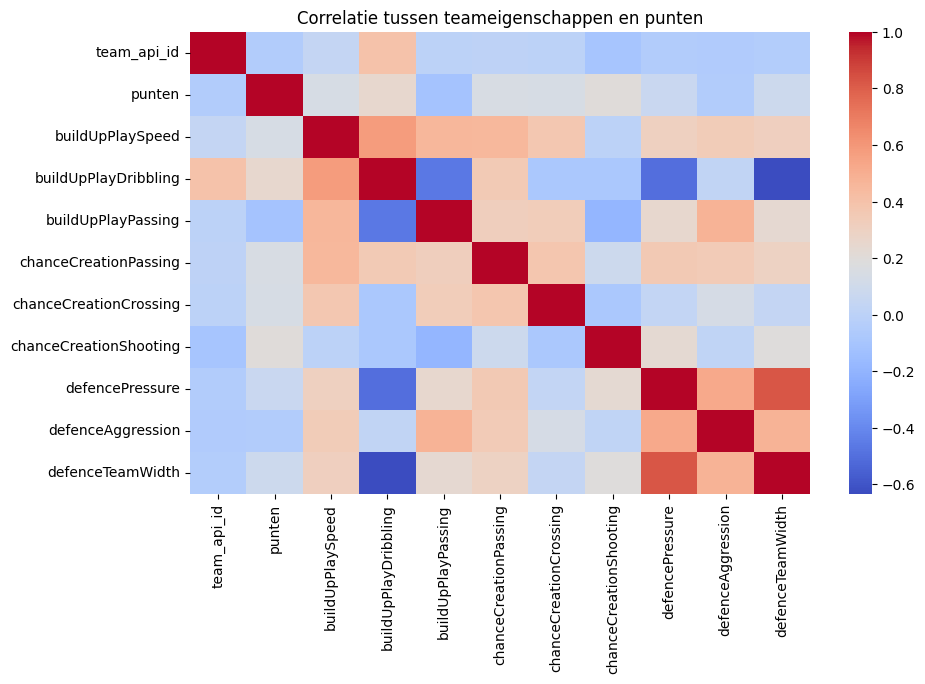

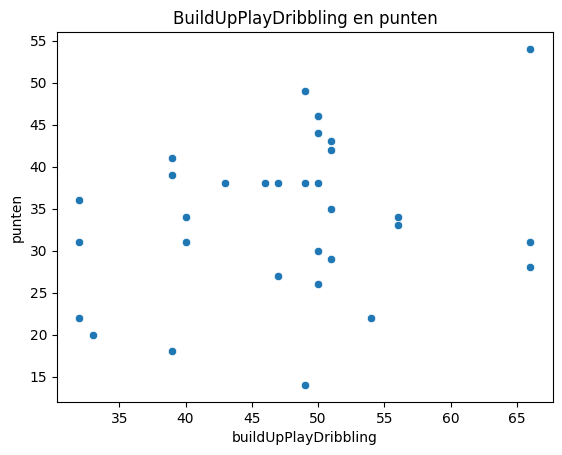

In [60]:

# heatmap
corr = samengevoegd_df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlatie tussen teameigenschappen en punten")
plt.show()

# scatterplot
sns.scatterplot(data=samengevoegd_df, x="buildUpPlayDribbling", y="punten")
plt.title("BuildUpPlayDribbling en punten")
plt.show()

